# Part 4.1 - Embeddings and Similarity

In this notebook I am working with sentence embeddings to see how well the model groups similar sentences together. I picked 3 topics and wrote 10 sentences total, then used cosine similarity to measure how close they are.

In [23]:
!pip install sentence-transformers -q
!pip install seaborn -q

In [24]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Step 1 - Define sentences

In [25]:
# wrote 10 sentences across 3 topics
# at least 3 per topic as required

sentences = [
    # cricket
    "The opening batsman scored a century before lunch on day one.",
    "Both teams were tied on points so the match went to a super over.",
    "The fast bowler swung the ball late and clean bowled the batsman.",
    "India needed 14 runs off the last over to win the series.",

    # cooking
    "I added too much salt so I put a raw potato in to absorb it.",
    "The dough needs to rest for at least an hour before you roll it out.",
    "Roasting garlic in the oven makes it soft and less sharp in taste.",

    # cybersecurity
    "Two factor authentication adds an extra layer of security to your account.",
    "The malware was hiding inside a legitimate looking PDF attachment.",
    "Always update your software because old versions have known security holes."
]

labels = [
    "Cric-1", "Cric-2", "Cric-3", "Cric-4",
    "Cook-1", "Cook-2", "Cook-3",
    "Cyber-1", "Cyber-2", "Cyber-3"
]

print("total sentences:", len(sentences))

total sentences: 10


## Step 2 - Generate embeddings using all-MiniLM-L6-v2

In [26]:
# loading the model - takes a minute first time
model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = model.encode(sentences)
print("embeddings shape:", embeddings.shape)
# 10 sentences x 384 dimensions

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


embeddings shape: (10, 384)


## Step 3 - Cosine Similarity Matrix (10x10)

In [27]:
sim_matrix = cosine_similarity(embeddings)
print(np.round(sim_matrix, 2))

[[ 1.    0.24  0.52  0.46  0.1   0.06  0.08  0.04  0.06 -0.  ]
 [ 0.24  1.    0.21  0.41  0.08  0.01  0.07  0.08  0.02 -0.07]
 [ 0.52  0.21  1.    0.35  0.07  0.11  0.08  0.03  0.09 -0.02]
 [ 0.46  0.41  0.35  1.    0.06  0.06  0.07  0.03  0.08  0.03]
 [ 0.1   0.08  0.07  0.06  1.    0.28  0.27  0.01  0.06  0.02]
 [ 0.06  0.01  0.11  0.06  0.28  1.    0.17 -0.03  0.06  0.  ]
 [ 0.08  0.07  0.08  0.07  0.27  0.17  1.    0.02  0.06  0.07]
 [ 0.04  0.08  0.03  0.03  0.01 -0.03  0.02  1.    0.06  0.19]
 [ 0.06  0.02  0.09  0.08  0.06  0.06  0.06  0.06  1.    0.34]
 [-0.   -0.07 -0.02  0.03  0.02  0.    0.07  0.19  0.34  1.  ]]


## Step 4 - Heatmap

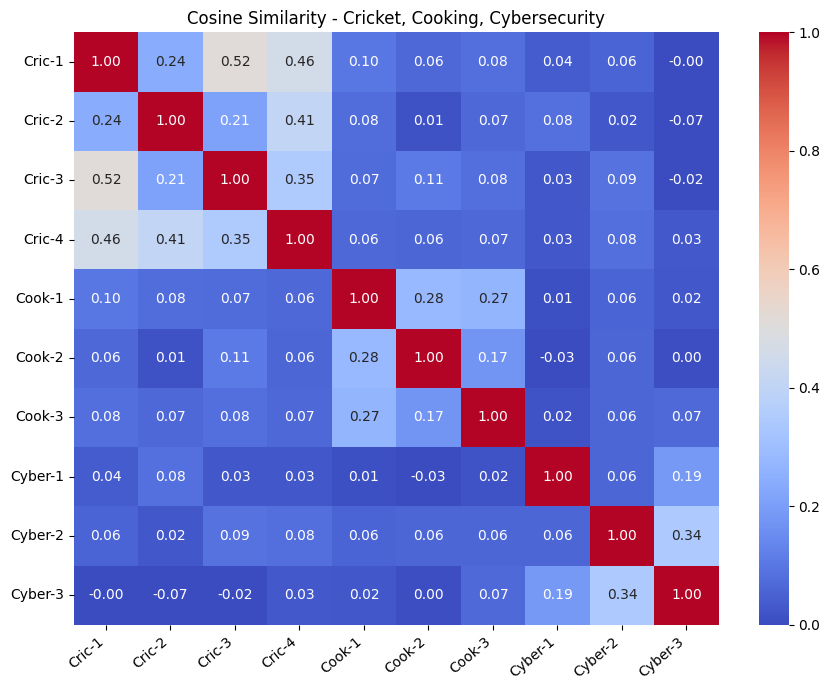

In [28]:
%matplotlib inline
plt.figure(figsize=(9, 7))
sns.heatmap(
    sim_matrix,
    xticklabels=labels,
    yticklabels=labels,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=0,
    vmax=1
)
plt.title("Cosine Similarity - Cricket, Cooking, Cybersecurity")
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

# same topic sentences are clearly more similar to each other
# you can see the 3 clusters in the heatmap

## Step 5 - Query: Top 2 similar sentences

In [29]:
query = "The bowler took three wickets in one over"
query_vec = model.encode([query])
scores = cosine_similarity(query_vec, embeddings)[0]
top2 = np.argsort(scores)[::-1][:2]

print("Query:", query)
print("\nTop 2 matches:\n")
for i, idx in enumerate(top2):
    print(f"Match {i+1}: {sentences[idx]}")
    print(f"Score  : {scores[idx]:.4f}")
    print()

Query: The bowler took three wickets in one over

Top 2 matches:

Match 1: The fast bowler swung the ball late and clean bowled the batsman.
Score  : 0.6713

Match 2: The opening batsman scored a century before lunch on day one.
Score  : 0.4929

